In [1]:
!pip install geopandas

In [2]:
# CELL 1: Set up the environment and locate the PO datasets

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
    print("GeoPandas is available.")
except ImportError:
    print("GeoPandas is not installed.")
    print("Run: !pip install geopandas")

# Folder containing all PO files
po_folder = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files"
)

# Separate folder for analysis outputs created later
analysis_output = po_folder / "Analysis_Output"
analysis_output.mkdir(parents=True, exist_ok=True)

print("\nPO data folder:")
print(po_folder)

print("\nAnalysis output folder:")
print(analysis_output)


# Locate the main PO files
sites_db_files = list(
    po_folder.glob("*sites_db*.csv")
)

quarterly_files = list(
    po_folder.glob("*street_segment_qtr_attributes*.csv")
)

street_spatial_files = list(
    po_folder.glob("*streets_spatial*.gpkg")
)

study_area_files = list(
    po_folder.glob("*street_spatial_study_area*.gpkg")
)

road_segment_files = list(
    po_folder.glob("*road_segments_15dec*.shp")
)


print("\n" + "=" * 65)
print("PO FILE AVAILABILITY")
print("=" * 65)

print("\nsites_db:")
for file in sites_db_files:
    print("-", file.name)

print("\nstreet_segment_qtr_attributes:")
for file in quarterly_files:
    print("-", file.name)

print("\nstreets_spatial:")
for file in street_spatial_files:
    print("-", file.name)

print("\nstreet_spatial_study_area:")
for file in study_area_files:
    print("-", file.name)

print("\nroad_segments_15dec:")
for file in road_segment_files:
    print("-", file.name)


print("\nFILE CHECK")

print("sites_db found:", len(sites_db_files) > 0)
print("quarterly attributes found:", len(quarterly_files) > 0)
print("street spatial found:", len(street_spatial_files) > 0)
print("study area found:", len(study_area_files) > 0)
print("road segments found:", len(road_segment_files) > 0)

GeoPandas is available.

PO data folder:
C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files

Analysis output folder:
C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files\Analysis_Output

PO FILE AVAILABILITY

sites_db:
- sites_db.csv

street_segment_qtr_attributes:
- street_segment_qtr_attributes.csv

streets_spatial:
- streets_spatial.gpkg

street_spatial_study_area:
- street_spatial_study_area.gpkg

road_segments_15dec:
- road_segments_15dec.shp

FILE CHECK
sites_db found: True
quarterly attributes found: True
street spatial found: True
study area found: True
road segments found: True


In [8]:
# CELL 2: Inspect the PO sites database and handle file encoding

sites_file = sites_db_files[0]

print("=" * 70)
print("SITES DATABASE")
print("=" * 70)

print("\nFile being inspected:")
print(sites_file)


# ------------------------------------------------------------
# STEP 1: Read the CSV using a suitable text encoding
# ------------------------------------------------------------

encodings_to_try = [
    "utf-8",
    "utf-8-sig",
    "cp1252",
    "latin1"
]

sites_df = None
encoding_used = None

for encoding in encodings_to_try:
    
    try:
        sites_df = pd.read_csv(
            sites_file,
            encoding=encoding,
            low_memory=False
        )
        
        encoding_used = encoding
        break
        
    except UnicodeDecodeError:
        continue


if sites_df is None:
    raise ValueError(
        "The CSV could not be read using the tested encodings."
    )


print("\nFILE ENCODING")
print("Encoding successfully used:", encoding_used)


# ------------------------------------------------------------
# STEP 2: Dataset dimensions
# ------------------------------------------------------------

print("\nDATASET SIZE")
print("Rows:", f"{sites_df.shape[0]:,}")
print("Columns:", sites_df.shape[1])


# ------------------------------------------------------------
# STEP 3: Column names
# ------------------------------------------------------------

print("\nCOLUMN NAMES")

for number, column in enumerate(
    sites_df.columns,
    start=1
):
    print(f"{number}. {column}")


# ------------------------------------------------------------
# STEP 4: Preview the data
# ------------------------------------------------------------

print("\nFIRST 5 ROWS")

display(
    sites_df.head()
)


# ------------------------------------------------------------
# STEP 5: Data types
# ------------------------------------------------------------

print("\nDATA TYPES")

print(
    sites_df.dtypes
)


# ------------------------------------------------------------
# STEP 6: Unique values in each column
# ------------------------------------------------------------

print("\nUNIQUE VALUE COUNTS")

for column in sites_df.columns:
    
    unique_values = sites_df[column].nunique(
        dropna=True
    )
    
    print(
        f"{column}: {unique_values:,}"
    )


# ------------------------------------------------------------
# STEP 7: Missing-value summary
# ------------------------------------------------------------

print("\nMISSING VALUES")

sites_missing = pd.DataFrame({
    
    "Column":
        sites_df.columns,
    
    "Missing_Values":
        sites_df.isna().sum().values,
    
    "Missing_Percentage":
        (
            sites_df.isna().sum().values
            / len(sites_df)
            * 100
        ).round(2)
})


sites_missing = (
    sites_missing
    .sort_values(
        "Missing_Values",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    sites_missing
)

SITES DATABASE

File being inspected:
C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files\sites_db.csv

FILE ENCODING
Encoding successfully used: cp1252

DATASET SIZE
Rows: 637
Columns: 35

COLUMN NAMES
1. InterventionID
2. SiteID
3. StreetSegmentID
4. SiteType
5. Baseline
6. StreetInScope
7. InterventionSiteID
8. DateOfIntervention/InitialCapture
9. DisruptionStartDate
10. DisruptionEndDate
11. InterventionType
12. NoChangeSince
13. StreetTrees
14. StreetTreesChange
15. StreetLighting
16. StreetLightingChange
17. StreetFurniture
18. StreetFurnitureChange
19. Placemaking
20. PlacemakingChange
21. Wayfinding
22. WayfindingChange
23. StreetInScopeOnStreetParking
24. StreetInScopeParkingFormat
25. StreetInScopeOnStreetParkingCapacity
26. BufferOnStreetParking
27. BufferOnStreetParkingFormat
28. BufferOnStreetParkingCapacity
29. OffStreetParking
30. OffStreetParkingCapacity
31. NumberOfTrafficLanes
32. PedestrianEstimatesAvgDay
33. InterventionSummary
34. InterventionSummaryExpa

,InterventionID,SiteID,StreetSegmentID,SiteType,Baseline,StreetInScope,InterventionSiteID,DateOfIntervention/InitialCapture,DisruptionStartDate,DisruptionEndDate,...,BufferOnStreetParking,BufferOnStreetParkingFormat,BufferOnStreetParkingCapacity,OffStreetParking,OffStreetParkingCapacity,NumberOfTrafficLanes,PedestrianEstimatesAvgDay,InterventionSummary,InterventionSummaryExpanded,Comment
0,control_id_1_11903,control_id_1,11903,Control,Yes,LYGON STREET,NaN,20251015,NaN,NaN,...,Yes,Mixed,High,Yes,Low,2.0,2360.0,NA Control Site,NA Control Site,NaN
1,control_id_10_3391,control_id_10,3391,Control,Yes,HIGH STREET,NaN,20251015,NaN,NaN,...,Yes,Parallel,High,No,NaN,2.0,2230.0,NA Control Site,NA Control Site,No Change since 12102009
2,control_id_101_4175,control_id_101,4175,Control,Yes,MURRUMBEENA ROAD,NaN,20251004,NaN,NaN,...,Yes,Parallel,Medium,Yes,High,4.0,1390.0,NA Control Site,NA Control Site,"Site Parking - ~ 8 spots S of Railway Pde, Off..."
3,control_id_102_3813,control_id_102,3813,Control,Yes,WATTON STREET,NaN,20251015,NaN,NaN,...,Yes,Mixed,Medium,Yes,High,2.0,2730.0,NA Control Site,NA Control Site,2 additional parking bays added on Watton St i...
4,control_id_103_12024,control_id_103,12024,Control,Yes,ERROL ST,NaN,20251015,NaN,NaN,...,Yes,Mixed,High,Yes,Low,2.0,3620.0,NA Control site,NA Control Site,Jan 22 2021: Shopfront extended onto road whic...



DATA TYPES
InterventionID                           object
SiteID                                   object
StreetSegmentID                           int64
SiteType                                 object
Baseline                                 object
StreetInScope                            object
InterventionSiteID                      float64
DateOfIntervention/InitialCapture         int64
DisruptionStartDate                     float64
DisruptionEndDate                       float64
InterventionType                         object
NoChangeSince                           float64
StreetTrees                              object
StreetTreesChange                        object
StreetLighting                           object
StreetLightingChange                     object
StreetFurniture                          object
StreetFurnitureChange                    object
Placemaking                              object
PlacemakingChange                        object
Wayfinding                  

,Column,Missing_Values,Missing_Percentage
0,InterventionSiteID,577,90.58
1,NoChangeSince,442,69.39
2,DisruptionStartDate,402,63.11
3,DisruptionEndDate,348,54.63
4,Comment,334,52.43
5,PlacemakingChange,240,37.68
6,StreetTreesChange,228,35.79
7,StreetLightingChange,226,35.48
8,WayfindingChange,224,35.16
9,StreetFurnitureChange,224,35.16


In [10]:
# CELL 3: Understand the structure and important categories in sites_db

print("=" * 70)
print("SITES DATABASE - STRUCTURE AND CATEGORY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# 1. Site type distribution
# ------------------------------------------------------------

print("\nSITE TYPE DISTRIBUTION")

site_type_summary = (
    sites_df["SiteType"]
    .value_counts(dropna=False)
    .rename_axis("SiteType")
    .reset_index(name="Records")
)

site_type_summary["Percentage"] = (
    site_type_summary["Records"]
    / len(sites_df)
    * 100
).round(2)

display(site_type_summary)


# ------------------------------------------------------------
# 2. Baseline values
# ------------------------------------------------------------

print("\nBASELINE VALUES")

display(
    sites_df["Baseline"]
    .value_counts(dropna=False)
    .rename_axis("Baseline")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 3. Number of unique identifiers
# ------------------------------------------------------------

print("\nIDENTIFIER SUMMARY")

print("Total rows:", f"{len(sites_df):,}")
print(
    "Unique Intervention IDs:",
    f"{sites_df['InterventionID'].nunique():,}"
)
print(
    "Unique Site IDs:",
    f"{sites_df['SiteID'].nunique():,}"
)
print(
    "Unique Street Segment IDs:",
    f"{sites_df['StreetSegmentID'].nunique():,}"
)


# ------------------------------------------------------------
# 4. Check exact duplicate rows
# ------------------------------------------------------------

exact_duplicates = sites_df.duplicated().sum()

print("\nEXACT DUPLICATE CHECK")
print("Exact duplicate rows:", f"{exact_duplicates:,}")


# ------------------------------------------------------------
# 5. Check repeated StreetSegmentID values
# ------------------------------------------------------------

segment_record_counts = (
    sites_df
    .groupby("StreetSegmentID")
    .size()
    .sort_values(ascending=False)
)

print("\nSTREET SEGMENT RECORD FREQUENCY")

print(
    "Segments appearing once:",
    f"{(segment_record_counts == 1).sum():,}"
)

print(
    "Segments appearing more than once:",
    f"{(segment_record_counts > 1).sum():,}"
)

print(
    "Maximum records for one StreetSegmentID:",
    f"{segment_record_counts.max():,}"
)

print("\nExamples of StreetSegmentIDs with multiple records:")

display(
    segment_record_counts[
        segment_record_counts > 1
    ]
    .head(10)
    .rename("Number_of_Records")
    .reset_index()
)


# ------------------------------------------------------------
# 6. Intervention type
# ------------------------------------------------------------

print("\nINTERVENTION TYPES")

display(
    sites_df["InterventionType"]
    .value_counts(dropna=False)
    .rename_axis("InterventionType")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 7. Parking-related categorical fields
# ------------------------------------------------------------

parking_columns = [
    "StreetInScopeOnStreetParking",
    "StreetInScopeParkingFormat",
    "BufferOnStreetParking",
    "BufferOnStreetParkingFormat",
    "OffStreetParking"
]

print("\nPARKING CATEGORY VALUES")

for column in parking_columns:
    
    print(f"\n{column}")
    
    display(
        sites_df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Records")
    )


# ------------------------------------------------------------
# 8. Missing values separated by SiteType
# ------------------------------------------------------------

important_columns = [
    "InterventionSiteID",
    "DisruptionStartDate",
    "DisruptionEndDate",
    "InterventionType",
    "StreetInScopeOnStreetParkingCapacity",
    "NumberOfTrafficLanes",
    "PedestrianEstimatesAvgDay"
]

print("\nMISSING VALUES BY SITE TYPE")

for site_type in sites_df["SiteType"].dropna().unique():
    
    subset = sites_df[
        sites_df["SiteType"] == site_type
    ]
    
    print(f"\n{site_type}")
    print("Records:", len(subset))
    
    missing_by_type = pd.DataFrame({
        "Column": important_columns,
        "Missing_Values": [
            subset[col].isna().sum()
            for col in important_columns
        ],
        "Missing_Percentage": [
            round(
                subset[col].isna().mean() * 100,
                2
            )
            for col in important_columns
        ]
    })
    
    display(missing_by_type)

SITES DATABASE - STRUCTURE AND CATEGORY CHECK

SITE TYPE DISTRIBUTION


,SiteType,Records,Percentage
0,Intervention,442,69.39
1,Control,195,30.61



BASELINE VALUES


,Baseline,Records
0,No,363
1,Yes,274



IDENTIFIER SUMMARY
Total rows: 637
Unique Intervention IDs: 274
Unique Site IDs: 152
Unique Street Segment IDs: 274

EXACT DUPLICATE CHECK
Exact duplicate rows: 0

STREET SEGMENT RECORD FREQUENCY
Segments appearing once: 195
Segments appearing more than once: 79
Maximum records for one StreetSegmentID: 14

Examples of StreetSegmentIDs with multiple records:


...

,OffStreetParking,Records
0,Yes,483
1,No,144
2,NaN,10



MISSING VALUES BY SITE TYPE

Control
Records: 195


,Column,Missing_Values,Missing_Percentage
0,InterventionSiteID,195,100.00
1,DisruptionStartDate,177,90.77
2,DisruptionEndDate,176,90.26
3,InterventionType,0,0.00
4,StreetInScopeOnStreetParkingCapacity,0,0.00
5,NumberOfTrafficLanes,0,0.00
6,PedestrianEstimatesAvgDay,0,0.00



Intervention
Records: 442


,Column,Missing_Values,Missing_Percentage
0,InterventionSiteID,382,86.43
1,DisruptionStartDate,225,50.90
2,DisruptionEndDate,172,38.91
3,InterventionType,5,1.13
4,StreetInScopeOnStreetParkingCapacity,10,2.26
5,NumberOfTrafficLanes,11,2.49
6,PedestrianEstimatesAvgDay,10,2.26


In [12]:
# CELL 4: Inspect the street segment quarterly attributes dataset

quarterly_file = quarterly_files[0]

print("=" * 70)
print("STREET SEGMENT QUARTERLY ATTRIBUTES")
print("=" * 70)

print("\nFile being inspected:")
print(quarterly_file)


# ------------------------------------------------------------
# 1. Read the dataset
# ------------------------------------------------------------

# Use the same encoding approach because this is another PO CSV.
encodings_to_try = [
    "utf-8",
    "utf-8-sig",
    "cp1252",
    "latin1"
]

quarterly_df = None
quarterly_encoding = None

for encoding in encodings_to_try:
    
    try:
        quarterly_df = pd.read_csv(
            quarterly_file,
            encoding=encoding,
            low_memory=False
        )
        
        quarterly_encoding = encoding
        break
        
    except UnicodeDecodeError:
        continue


if quarterly_df is None:
    raise ValueError(
        "The quarterly CSV could not be read using the tested encodings."
    )


print("\nFILE ENCODING")
print("Encoding successfully used:", quarterly_encoding)


# ------------------------------------------------------------
# 2. Dataset dimensions
# ------------------------------------------------------------

print("\nDATASET SIZE")
print("Rows:", f"{quarterly_df.shape[0]:,}")
print("Columns:", quarterly_df.shape[1])


# ------------------------------------------------------------
# 3. Column names
# ------------------------------------------------------------

print("\nCOLUMN NAMES")

for number, column in enumerate(
    quarterly_df.columns,
    start=1
):
    print(f"{number}. {column}")


# ------------------------------------------------------------
# 4. Preview
# ------------------------------------------------------------

print("\nFIRST 5 ROWS")

display(
    quarterly_df.head()
)


# ------------------------------------------------------------
# 5. Data types
# ------------------------------------------------------------

print("\nDATA TYPES")

print(
    quarterly_df.dtypes
)


# ------------------------------------------------------------
# 6. Unique values
# ------------------------------------------------------------

print("\nUNIQUE VALUE COUNTS")

for column in quarterly_df.columns:
    
    unique_count = quarterly_df[column].nunique(
        dropna=True
    )
    
    print(
        f"{column}: {unique_count:,}"
    )


# ------------------------------------------------------------
# 7. Missing values
# ------------------------------------------------------------

print("\nMISSING VALUES")

quarterly_missing = pd.DataFrame({
    
    "Column":
        quarterly_df.columns,
    
    "Missing_Values":
        quarterly_df.isna().sum().values,
    
    "Missing_Percentage":
        (
            quarterly_df.isna().sum().values
            / len(quarterly_df)
            * 100
        ).round(2)
})


quarterly_missing = (
    quarterly_missing
    .sort_values(
        "Missing_Values",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    quarterly_missing
)


# ------------------------------------------------------------
# 8. Exact duplicate check
# ------------------------------------------------------------

print("\nEXACT DUPLICATE CHECK")

print(
    "Exact duplicate rows:",
    f"{quarterly_df.duplicated().sum():,}"
)

STREET SEGMENT QUARTERLY ATTRIBUTES

File being inspected:
C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files\street_segment_qtr_attributes.csv

FILE ENCODING
Encoding successfully used: utf-8

DATASET SIZE
Rows: 30,783
Columns: 15

COLUMN NAMES
1. Unnamed: 0
2. QUARTER
3. SiteID
4. STREET_SEGMENT_ID
5. Baseline
6. InterventionType
7. InterventionSummary
8. is_under_construction
9. other_major_construction
10. StreetInScopeOnStreetParking
11. StreetInScopeParkingFormat
12. StreetInScopeOnStreetParkingCap
13. BufferOnStreetParking
14. BufferOnStreetParkingCapacity
15. BufferOnStreetParkingFormat

FIRST 5 ROWS


,Unnamed: 0,QUARTER,SiteID,STREET_SEGMENT_ID,Baseline,InterventionType,InterventionSummary,is_under_construction,other_major_construction,StreetInScopeOnStreetParking,StreetInScopeParkingFormat,StreetInScopeOnStreetParkingCap,BufferOnStreetParking,BufferOnStreetParkingCapacity,BufferOnStreetParkingFormat
0,1,9900Q2,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
1,2,9900Q3,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
2,3,9900Q4,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
3,4,0001Q1,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel
4,5,0001Q2,1,12016,NaN,NaN,NaN,0.0,0.0,1,Parallel,7,1.0,Medium,Parallel



DATA TYPES
Unnamed: 0                           int64
QUARTER                             object
SiteID                              object
STREET_SEGMENT_ID                    int64
Baseline                           float64
InterventionType                    object
InterventionSummary                 object
is_under_construction              float64
other_major_construction           float64
StreetInScopeOnStreetParking         int64
StreetInScopeParkingFormat          object
StreetInScopeOnStreetParkingCap      int64
BufferOnStreetParking              float64
BufferOnStreetParkingCapacity       object
BufferOnStreetParkingFormat         object
dtype: object

UNIQUE VALUE COUNTS
Unnamed: 0: 30,783
QUARTER: 105
SiteID: 167
STREET_SEGMENT_ID: 292
Baseline: 2
InterventionType: 4
InterventionSummary: 25
is_under_construction: 2
other_major_construction: 2
StreetInScopeOnStreetParking: 2
StreetInScopeParkingFormat: 4
StreetInScopeOnStreetParkingCap: 135
BufferOnStreetParking: 2
BufferOn

,Column,Missing_Values,Missing_Percentage
0,Baseline,30140,97.91
1,InterventionType,30140,97.91
2,InterventionSummary,30140,97.91
3,BufferOnStreetParkingFormat,2837,9.22
4,is_under_construction,2626,8.53
5,BufferOnStreetParking,2626,8.53
6,BufferOnStreetParkingCapacity,2626,8.53
7,other_major_construction,1575,5.12
8,StreetInScopeParkingFormat,877,2.85
9,Unnamed: 0,0,0.00



EXACT DUPLICATE CHECK
Exact duplicate rows: 0


In [14]:
# CELL 5: Analyse quarterly coverage and construction periods

print("=" * 70)
print("QUARTERLY COVERAGE AND CONSTRUCTION ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Inspect the quarter values in their existing order
# ------------------------------------------------------------

quarter_values = quarterly_df["QUARTER"].dropna().unique()

print("\nQUARTER COVERAGE")
print("Number of unique quarters:", len(quarter_values))

print("\nFirst 15 quarter values:")
print(quarter_values[:15])

print("\nLast 15 quarter values:")
print(quarter_values[-15:])


# ------------------------------------------------------------
# 2. Records and street segments per quarter
# ------------------------------------------------------------

quarter_coverage = (
    quarterly_df
    .groupby("QUARTER", sort=False)
    .agg(
        Records=("STREET_SEGMENT_ID", "size"),
        Unique_Street_Segments=("STREET_SEGMENT_ID", "nunique"),
        Unique_Sites=("SiteID", "nunique")
    )
    .reset_index()
)

print("\nQUARTER-BY-QUARTER COVERAGE")

display(
    quarter_coverage.head(15)
)

print("\nLast 15 quarters:")

display(
    quarter_coverage.tail(15)
)


# ------------------------------------------------------------
# 3. Number of quarterly observations per street segment
# ------------------------------------------------------------

segment_quarter_counts = (
    quarterly_df
    .groupby("STREET_SEGMENT_ID")["QUARTER"]
    .nunique()
)

print("\nSTREET SEGMENT TEMPORAL COVERAGE")

print(
    "Minimum quarters for a street segment:",
    segment_quarter_counts.min()
)

print(
    "Maximum quarters for a street segment:",
    segment_quarter_counts.max()
)

print(
    "Median quarters for a street segment:",
    segment_quarter_counts.median()
)

print(
    "Average quarters for a street segment:",
    round(segment_quarter_counts.mean(), 2)
)


print("\nDistribution of quarter coverage:")

display(
    segment_quarter_counts
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Quarters")
    .reset_index(name="Street_Segments")
)


# ------------------------------------------------------------
# 4. Construction field values
# ------------------------------------------------------------

print("\nIS_UNDER_CONSTRUCTION VALUES")

display(
    quarterly_df["is_under_construction"]
    .value_counts(dropna=False)
    .rename_axis("is_under_construction")
    .reset_index(name="Records")
)


print("\nOTHER_MAJOR_CONSTRUCTION VALUES")

display(
    quarterly_df["other_major_construction"]
    .value_counts(dropna=False)
    .rename_axis("other_major_construction")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 5. Number of segments that have construction records
# ------------------------------------------------------------

construction_records = quarterly_df[
    quarterly_df["is_under_construction"] == 1
]

print("\nCONSTRUCTION RECORD SUMMARY")

print(
    "Records marked as under construction:",
    f"{len(construction_records):,}"
)

print(
    "Street segments with at least one construction quarter:",
    f"{construction_records['STREET_SEGMENT_ID'].nunique():,}"
)

print(
    "Sites with at least one construction quarter:",
    f"{construction_records['SiteID'].nunique():,}"
)


# ------------------------------------------------------------
# 6. Construction records by quarter
# ------------------------------------------------------------

construction_by_quarter = (
    construction_records
    .groupby("QUARTER", sort=False)
    .agg(
        Construction_Records=("STREET_SEGMENT_ID", "size"),
        Street_Segments=("STREET_SEGMENT_ID", "nunique"),
        Sites=("SiteID", "nunique")
    )
    .reset_index()
)

print("\nCONSTRUCTION ACTIVITY BY QUARTER")

display(
    construction_by_quarter
)


# ------------------------------------------------------------
# 7. Number of construction quarters for each affected segment
# ------------------------------------------------------------

construction_duration = (
    construction_records
    .groupby("STREET_SEGMENT_ID")["QUARTER"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nCONSTRUCTION QUARTERS PER AFFECTED STREET SEGMENT")

if len(construction_duration) > 0:

    print(
        "Minimum construction quarters:",
        construction_duration.min()
    )

    print(
        "Maximum construction quarters:",
        construction_duration.max()
    )

    print(
        "Median construction quarters:",
        construction_duration.median()
    )

    print("\nSegments with the most construction quarters:")

    display(
        construction_duration
        .head(15)
        .rename("Construction_Quarters")
        .reset_index()
    )

else:
    print("No construction records were found.")


# ------------------------------------------------------------
# 8. Check whether a segment-quarter combination is unique
# ------------------------------------------------------------

segment_quarter_duplicates = quarterly_df.duplicated(
    subset=[
        "STREET_SEGMENT_ID",
        "QUARTER"
    ],
    keep=False
)

print("\nSEGMENT + QUARTER UNIQUENESS CHECK")

print(
    "Rows involved in repeated segment-quarter combinations:",
    f"{segment_quarter_duplicates.sum():,}"
)

print(
    "Unique repeated segment-quarter combinations:",
    f"{quarterly_df.loc[segment_quarter_duplicates, ['STREET_SEGMENT_ID', 'QUARTER']].drop_duplicates().shape[0]:,}"
)

QUARTERLY COVERAGE AND CONSTRUCTION ANALYSIS

QUARTER COVERAGE
Number of unique quarters: 105

First 15 quarter values:
['9900Q2' '9900Q3' '9900Q4' '0001Q1' '0001Q2' '0001Q3' '0001Q4' '0102Q1'
 '0102Q2' '0102Q3' '0102Q4' '0203Q1' '0203Q2' '0203Q3' '0203Q4']

Last 15 quarter values:
['2122Q4' '2223Q1' '2223Q2' '2223Q3' '2223Q4' '2324Q1' '2324Q2' '2324Q3'
 '2324Q4' '2425Q1' '2425Q2' '2425Q3' '2425Q4' '2526Q1' '2526Q2']

QUARTER-BY-QUARTER COVERAGE


,QUARTER,Records,Unique_Street_Segments,Unique_Sites
0,9900Q2,293,292,167
1,9900Q3,293,292,167
2,9900Q4,293,292,167
3,0001Q1,293,292,167
4,0001Q2,293,292,167
5,0001Q3,293,292,167
6,0001Q4,293,292,167
7,0102Q1,293,292,167
8,0102Q2,293,292,167
9,0102Q3,293,292,167



Last 15 quarters:


,QUARTER,Records,Unique_Street_Segments,Unique_Sites
90,2122Q4,293,292,167
91,2223Q1,293,292,167
92,2223Q2,293,292,167
93,2223Q3,294,292,167
94,2223Q4,293,292,167
95,2324Q1,293,292,167
96,2324Q2,293,292,167
97,2324Q3,293,292,167
98,2324Q4,293,292,167
99,2425Q1,293,292,167



STREET SEGMENT TEMPORAL COVERAGE
Minimum quarters for a street segment: 105
Maximum quarters for a street segment: 105
Median quarters for a street segment: 105.0
Average quarters for a street segment: 105.0

Distribution of quarter coverage:


...


CONSTRUCTION RECORD SUMMARY
Records marked as under construction: 189
Street segments with at least one construction quarter: 69
Sites with at least one construction quarter: 29

CONSTRUCTION ACTIVITY BY QUARTER


,QUARTER,Construction_Records,Street_Segments,Sites
0,2021Q2,17,17,9
1,2021Q3,13,12,7
2,2021Q4,9,8,5
3,2122Q1,5,5,3
4,1011Q2,3,3,3
5,1011Q3,3,3,3
6,1011Q4,3,3,3
7,1718Q4,4,4,3
8,1819Q1,5,4,3
9,1819Q2,4,4,2



CONSTRUCTION QUARTERS PER AFFECTED STREET SEGMENT
Minimum construction quarters: 1
Maximum construction quarters: 9
Median construction quarters: 2.0

Segments with the most construction quarters:


,STREET_SEGMENT_ID,Construction_Quarters
0,7749,9
1,7748,9
2,5639,8
3,5637,7
4,5082,5
5,6626,5
6,9804,5
7,7327,4
8,7326,4
9,7325,4



SEGMENT + QUARTER UNIQUENESS CHECK
Rows involved in repeated segment-quarter combinations: 246
Unique repeated segment-quarter combinations: 123


In [16]:
# CELL 6: Investigate repeated segment-quarter records and intervention metadata

print("=" * 70)
print("QUARTERLY RECORD STRUCTURE AND INTERVENTION METADATA")
print("=" * 70)


# ------------------------------------------------------------
# 1. Investigate repeated segment + quarter combinations
# ------------------------------------------------------------

repeated_rows = quarterly_df[
    quarterly_df.duplicated(
        subset=[
            "STREET_SEGMENT_ID",
            "QUARTER"
        ],
        keep=False
    )
].copy()


print("\nREPEATED SEGMENT-QUARTER RECORDS")

print(
    "Rows involved:",
    f"{len(repeated_rows):,}"
)

print(
    "Street segments involved:",
    repeated_rows["STREET_SEGMENT_ID"].nunique()
)

print(
    "Site IDs involved:",
    repeated_rows["SiteID"].nunique()
)


print("\nStreet segments involved in repeated combinations:")

display(
    repeated_rows[
        [
            "STREET_SEGMENT_ID",
            "SiteID"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "STREET_SEGMENT_ID",
            "SiteID"
        ]
    )
)


# ------------------------------------------------------------
# 2. Look at examples of repeated records
# ------------------------------------------------------------

print("\nEXAMPLE REPEATED RECORDS")

display(
    repeated_rows[
        [
            "QUARTER",
            "SiteID",
            "STREET_SEGMENT_ID",
            "Baseline",
            "InterventionType",
            "is_under_construction",
            "StreetInScopeOnStreetParkingCap"
        ]
    ]
    .sort_values(
        [
            "STREET_SEGMENT_ID",
            "QUARTER",
            "SiteID"
        ]
    )
    .head(30)
)


# ------------------------------------------------------------
# 3. Check whether repeated rows have different SiteIDs
# ------------------------------------------------------------

site_ids_per_segment_quarter = (
    repeated_rows
    .groupby(
        [
            "STREET_SEGMENT_ID",
            "QUARTER"
        ]
    )["SiteID"]
    .nunique()
)

print("\nSITE ID DIFFERENCE WITHIN REPEATED RECORDS")

print(
    "Repeated combinations with more than one SiteID:",
    int(
        (
            site_ids_per_segment_quarter > 1
        ).sum()
    )
)

print(
    "Repeated combinations with the same SiteID:",
    int(
        (
            site_ids_per_segment_quarter == 1
        ).sum()
    )
)


# ------------------------------------------------------------
# 4. Investigate non-null Baseline records
# ------------------------------------------------------------

baseline_records = quarterly_df[
    quarterly_df["Baseline"].notna()
].copy()

print("\nBASELINE FIELD")

print(
    "Records where Baseline is populated:",
    f"{len(baseline_records):,}"
)

print("\nBaseline values:")

display(
    baseline_records["Baseline"]
    .value_counts(dropna=False)
    .rename_axis("Baseline")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 5. Investigate intervention metadata
# ------------------------------------------------------------

intervention_metadata = quarterly_df[
    quarterly_df["InterventionType"].notna()
].copy()

print("\nINTERVENTION METADATA")

print(
    "Records with InterventionType populated:",
    f"{len(intervention_metadata):,}"
)

print(
    "Street segments represented:",
    intervention_metadata[
        "STREET_SEGMENT_ID"
    ].nunique()
)

print(
    "Sites represented:",
    intervention_metadata[
        "SiteID"
    ].nunique()
)


print("\nIntervention types:")

display(
    intervention_metadata[
        "InterventionType"
    ]
    .value_counts(dropna=False)
    .rename_axis("InterventionType")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 6. Check which quarters contain intervention metadata
# ------------------------------------------------------------

metadata_by_quarter = (
    intervention_metadata
    .groupby(
        "QUARTER",
        sort=False
    )
    .agg(
        Records=(
            "STREET_SEGMENT_ID",
            "size"
        ),
        Street_Segments=(
            "STREET_SEGMENT_ID",
            "nunique"
        ),
        Sites=(
            "SiteID",
            "nunique"
        )
    )
    .reset_index()
)

print("\nQUARTERS WITH INTERVENTION METADATA")

display(
    metadata_by_quarter
)


# ------------------------------------------------------------
# 7. See whether metadata appears once or repeatedly per segment
# ------------------------------------------------------------

metadata_frequency = (
    intervention_metadata
    .groupby(
        "STREET_SEGMENT_ID"
    )
    .size()
)

print("\nINTERVENTION METADATA FREQUENCY PER STREET SEGMENT")

print(
    "Minimum populated records per segment:",
    metadata_frequency.min()
)

print(
    "Maximum populated records per segment:",
    metadata_frequency.max()
)

print(
    "Median populated records per segment:",
    metadata_frequency.median()
)


display(
    metadata_frequency
    .value_counts()
    .sort_index()
    .rename_axis(
        "Populated_Records_Per_Segment"
    )
    .reset_index(
        name="Street_Segments"
    )
)


# ------------------------------------------------------------
# 8. Check whether intervention metadata appears during construction
# ------------------------------------------------------------

metadata_construction_check = pd.crosstab(
    intervention_metadata[
        "InterventionType"
    ],
    intervention_metadata[
        "is_under_construction"
    ],
    dropna=False
)

print("\nINTERVENTION TYPE VS CONSTRUCTION STATUS")

display(
    metadata_construction_check
)

QUARTERLY RECORD STRUCTURE AND INTERVENTION METADATA

REPEATED SEGMENT-QUARTER RECORDS
Rows involved: 246
Street segments involved: 19
Site IDs involved: 9

Street segments involved in repeated combinations:


,STREET_SEGMENT_ID,SiteID
4609,123,42
4715,124,42
4821,125,42
3131,3124,34
28577,3372,48
12827,3372,control_id_131
6783,3828,8
6889,3829,8
6995,3831,8
7101,3832,8



EXAMPLE REPEATED RECORDS


,QUARTER,SiteID,STREET_SEGMENT_ID,Baseline,InterventionType,is_under_construction,StreetInScopeOnStreetParkingCap
4609,2122Q2,42,123,1.0,ProtectedBikeLane,1.0,42
4610,2122Q2,42,123,0.0,ProtectedBikeLane,1.0,27
4715,2122Q2,42,124,1.0,ProtectedBikeLane,1.0,58
4716,2122Q2,42,124,0.0,ProtectedBikeLane,1.0,44
4821,2122Q2,42,125,1.0,ProtectedBikeLane,1.0,63
4822,2122Q2,42,125,0.0,ProtectedBikeLane,1.0,60
3131,2021Q4,34,3124,1.0,ProtectedBikeLane,1.0,50
3132,2021Q4,34,3124,0.0,ProtectedBikeLane,1.0,34
28577,0001Q1,48,3372,NaN,NaN,NaN,66
12830,0001Q1,control_id_131,3372,NaN,NaN,0.0,65



SITE ID DIFFERENCE WITHIN REPEATED RECORDS
Repeated combinations with more than one SiteID: 105
Repeated combinations with the same SiteID: 18

BASELINE FIELD
Records where Baseline is populated: 643

Baseline values:


...

,QUARTER,Records,Street_Segments,Sites
0,2021Q2,22,22,8
1,2021Q3,28,26,9
2,2122Q1,5,5,3
3,1011Q2,2,2,1
4,1011Q4,12,12,3
5,1718Q4,12,12,5
6,1819Q2,7,7,2
7,0910Q2,19,19,5
8,0910Q4,14,14,5
9,1718Q1,8,7,2



INTERVENTION METADATA FREQUENCY PER STREET SEGMENT
Minimum populated records per segment: 1
Maximum populated records per segment: 14
Median populated records per segment: 1.0


,Populated_Records_Per_Segment,Street_Segments
0,1,204
1,2,25
2,3,19
3,4,6
4,5,12
5,7,9
6,8,6
7,10,2
8,11,2
9,12,1



INTERVENTION TYPE VS CONSTRUCTION STATUS


is_under_construction,0.0,1.0,NaN
InterventionType,,,
Control,193,0,0
Pedestrianisation,0,12,0
ProtectedBikeLane,272,105,0
Regional Reallocation,0,0,61


In [18]:
# CELL 7: Analyse parking capacity and baseline/intervention differences

print("=" * 70)
print("PARKING CAPACITY AND BASELINE ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Basic parking capacity statistics
# ------------------------------------------------------------

print("\nSTREET-IN-SCOPE PARKING CAPACITY")

print(
    quarterly_df[
        "StreetInScopeOnStreetParkingCap"
    ].describe()
)


print("\nPARKING CAPACITY RANGE")

print(
    "Minimum:",
    quarterly_df[
        "StreetInScopeOnStreetParkingCap"
    ].min()
)

print(
    "Maximum:",
    quarterly_df[
        "StreetInScopeOnStreetParkingCap"
    ].max()
)

print(
    "Median:",
    quarterly_df[
        "StreetInScopeOnStreetParkingCap"
    ].median()
)


# ------------------------------------------------------------
# 2. Parking availability values
# ------------------------------------------------------------

print("\nON-STREET PARKING AVAILABILITY")

display(
    quarterly_df[
        "StreetInScopeOnStreetParking"
    ]
    .value_counts(dropna=False)
    .rename_axis("Parking_Available")
    .reset_index(name="Records")
)


print("\nPARKING FORMAT")

display(
    quarterly_df[
        "StreetInScopeParkingFormat"
    ]
    .value_counts(dropna=False)
    .rename_axis("Parking_Format")
    .reset_index(name="Records")
)


# ------------------------------------------------------------
# 3. Parking capacity by Baseline status
# ------------------------------------------------------------

baseline_parking = quarterly_df[
    quarterly_df["Baseline"].notna()
].copy()


print("\nPARKING CAPACITY BY BASELINE STATUS")

baseline_parking_summary = (
    baseline_parking
    .groupby("Baseline")[
        "StreetInScopeOnStreetParkingCap"
    ]
    .agg(
        Records="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

baseline_parking_summary[
    ["Mean", "Median"]
] = baseline_parking_summary[
    ["Mean", "Median"]
].round(2)

display(
    baseline_parking_summary
)


# ------------------------------------------------------------
# 4. Find segment/quarter records containing both
#    baseline and non-baseline versions
# ------------------------------------------------------------

baseline_pair_counts = (
    baseline_parking
    .groupby(
        [
            "STREET_SEGMENT_ID",
            "QUARTER"
        ]
    )["Baseline"]
    .nunique()
)

paired_keys = baseline_pair_counts[
    baseline_pair_counts > 1
].index


paired_records = (
    baseline_parking
    .set_index(
        [
            "STREET_SEGMENT_ID",
            "QUARTER"
        ]
    )
    .loc[paired_keys]
    .reset_index()
)


print("\nBASELINE / NON-BASELINE PAIRS")

print(
    "Segment-quarter combinations containing both states:",
    len(paired_keys)
)

print(
    "Street segments represented:",
    paired_records[
        "STREET_SEGMENT_ID"
    ].nunique()
)


# ------------------------------------------------------------
# 5. Compare parking capacity within paired observations
# ------------------------------------------------------------

parking_comparison = (
    paired_records
    .pivot_table(
        index=[
            "STREET_SEGMENT_ID",
            "QUARTER",
            "SiteID"
        ],
        columns="Baseline",
        values="StreetInScopeOnStreetParkingCap",
        aggfunc="first"
    )
    .reset_index()
)


# Rename baseline values for easier interpretation
parking_comparison = parking_comparison.rename(
    columns={
        0.0: "Non_Baseline_Capacity",
        1.0: "Baseline_Capacity"
    }
)


# Only compare records where both capacities exist
if (
    "Baseline_Capacity" in parking_comparison.columns
    and
    "Non_Baseline_Capacity" in parking_comparison.columns
):

    parking_comparison = parking_comparison.dropna(
        subset=[
            "Baseline_Capacity",
            "Non_Baseline_Capacity"
        ]
    )

    parking_comparison[
        "Capacity_Change"
    ] = (
        parking_comparison[
            "Non_Baseline_Capacity"
        ]
        -
        parking_comparison[
            "Baseline_Capacity"
        ]
    )


    print("\nPAIRED PARKING CAPACITY COMPARISON")

    display(
        parking_comparison.head(20)
    )


    print("\nCAPACITY CHANGE SUMMARY")

    print(
        parking_comparison[
            "Capacity_Change"
        ].describe()
    )


    print(
        "\nCapacity decreased:",
        (
            parking_comparison[
                "Capacity_Change"
            ] < 0
        ).sum()
    )

    print(
        "No capacity change:",
        (
            parking_comparison[
                "Capacity_Change"
            ] == 0
        ).sum()
    )

    print(
        "Capacity increased:",
        (
            parking_comparison[
                "Capacity_Change"
            ] > 0
        ).sum()
    )

else:

    print(
        "\nNo directly comparable baseline/non-baseline "
        "capacity pairs were found."
    )


# ------------------------------------------------------------
# 6. Parking capacity by intervention type
# ------------------------------------------------------------

print("\nPARKING CAPACITY BY INTERVENTION TYPE")

intervention_parking_summary = (
    intervention_metadata
    .groupby("InterventionType")[
        "StreetInScopeOnStreetParkingCap"
    ]
    .agg(
        Records="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

intervention_parking_summary[
    ["Mean", "Median"]
] = intervention_parking_summary[
    ["Mean", "Median"]
].round(2)

display(
    intervention_parking_summary
)


# ------------------------------------------------------------
# 7. Identify segments where parking capacity changes over time
# ------------------------------------------------------------

capacity_variation = (
    quarterly_df
    .groupby(
        "STREET_SEGMENT_ID"
    )[
        "StreetInScopeOnStreetParkingCap"
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
)


print("\nPARKING CAPACITY CHANGES ACROSS TIME")

print(
    "Segments with one recorded capacity:",
    (
        capacity_variation == 1
    ).sum()
)

print(
    "Segments with more than one recorded capacity:",
    (
        capacity_variation > 1
    ).sum()
)

print(
    "Maximum number of different capacities for one segment:",
    capacity_variation.max()
)


print("\nSegments with the most capacity variation:")

display(
    capacity_variation
    .head(15)
    .rename(
        "Number_of_Different_Capacities"
    )
    .reset_index()
)

PARKING CAPACITY AND BASELINE ANALYSIS

STREET-IN-SCOPE PARKING CAPACITY
count    30783.000000
mean        59.061982
std         52.064876
min          0.000000
25%         24.000000
50%         47.000000
75%         75.000000
max        293.000000
Name: StreetInScopeOnStreetParkingCap, dtype: float64

PARKING CAPACITY RANGE
Minimum: 0
Maximum: 293
Median: 47.0

ON-STREET PARKING AVAILABILITY


,Parking_Available,Records
0,1,29856
1,0,927



PARKING FORMAT


,Parking_Format,Records
0,Parallel,24059
1,Mixed,4345
2,Angled,1470
3,NaN,877
4,None (construction),32



PARKING CAPACITY BY BASELINE STATUS


...

Baseline,STREET_SEGMENT_ID,QUARTER,SiteID,Non_Baseline_Capacity,Baseline_Capacity,Capacity_Change
0,123,2122Q2,42,27,42,-15
1,124,2122Q2,42,44,58,-14
2,125,2122Q2,42,60,63,-3
3,3124,2021Q4,34,34,50,-16
4,3828,1213Q3,8,24,24,0
5,3829,1213Q3,8,34,34,0
6,3831,1213Q3,8,27,27,0
7,3832,1213Q3,8,40,40,0
8,3833,1213Q3,8,30,30,0
9,3834,1213Q3,8,43,43,0



CAPACITY CHANGE SUMMARY
count    11.000000
mean     -4.363636
std       6.903227
min     -16.000000
25%      -8.500000
50%       0.000000
75%       0.000000
max       0.000000
Name: Capacity_Change, dtype: float64

Capacity decreased: 4
No capacity change: 7
Capacity increased: 0

PARKING CAPACITY BY INTERVENTION TYPE


,InterventionType,Records,Mean,Median,Minimum,Maximum
0,Control,193,57.27,49.0,0,245
1,Pedestrianisation,12,6.58,3.5,0,30
2,ProtectedBikeLane,377,39.30,26.0,0,293
3,Regional Reallocation,61,106.87,110.0,0,229



PARKING CAPACITY CHANGES ACROSS TIME
Segments with one recorded capacity: 211
Segments with more than one recorded capacity: 81
Maximum number of different capacities for one segment: 8

Segments with the most capacity variation:


,STREET_SEGMENT_ID,Number_of_Different_Capacities
0,3832,8
1,3829,7
2,3831,7
3,6624,6
4,6626,6
5,3752,5
6,3750,5
7,9800,5
8,3751,5
9,1659,5


In [20]:
# CELL 8: Examine parking capacity changes around construction periods

print("=" * 70)
print("PARKING CAPACITY CHANGES AROUND CONSTRUCTION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create a working copy
# ------------------------------------------------------------

construction_df = quarterly_df.copy()


# ------------------------------------------------------------
# 2. Create an ordered quarter position
#    using the existing dataset order
# ------------------------------------------------------------

quarter_order = {
    quarter: position
    for position, quarter in enumerate(
        construction_df["QUARTER"].drop_duplicates()
    )
}

construction_df["Quarter_Order"] = (
    construction_df["QUARTER"]
    .map(quarter_order)
)


# ------------------------------------------------------------
# 3. Identify segments with construction
# ------------------------------------------------------------

segments_with_construction = (
    construction_df.loc[
        construction_df["is_under_construction"] == 1,
        "STREET_SEGMENT_ID"
    ]
    .unique()
)

print(
    "\nStreet segments with construction:",
    len(segments_with_construction)
)


# ------------------------------------------------------------
# 4. Find first and last construction quarter per segment
# ------------------------------------------------------------

construction_periods = (
    construction_df[
        construction_df["is_under_construction"] == 1
    ]
    .groupby("STREET_SEGMENT_ID")
    .agg(
        First_Construction_Order=(
            "Quarter_Order",
            "min"
        ),
        Last_Construction_Order=(
            "Quarter_Order",
            "max"
        ),
        Construction_Quarters=(
            "QUARTER",
            "nunique"
        )
    )
    .reset_index()
)


print("\nCONSTRUCTION PERIOD SUMMARY")

display(
    construction_periods.head(15)
)


# ------------------------------------------------------------
# 5. Find parking capacity immediately before construction
# ------------------------------------------------------------

before_records = []

for _, row in construction_periods.iterrows():

    segment_id = row["STREET_SEGMENT_ID"]
    first_order = row["First_Construction_Order"]

    segment_data = construction_df[
        construction_df["STREET_SEGMENT_ID"] == segment_id
    ]

    before_candidates = segment_data[
        segment_data["Quarter_Order"] < first_order
    ]

    if not before_candidates.empty:

        closest_order = (
            before_candidates["Quarter_Order"].max()
        )

        closest_records = before_candidates[
            before_candidates["Quarter_Order"]
            == closest_order
        ]

        for _, record in closest_records.iterrows():

            before_records.append({
                "STREET_SEGMENT_ID": segment_id,
                "Before_Quarter": record["QUARTER"],
                "Before_Capacity":
                    record["StreetInScopeOnStreetParkingCap"]
            })


before_df = pd.DataFrame(before_records)


# ------------------------------------------------------------
# 6. Find parking capacity immediately after construction
# ------------------------------------------------------------

after_records = []

for _, row in construction_periods.iterrows():

    segment_id = row["STREET_SEGMENT_ID"]
    last_order = row["Last_Construction_Order"]

    segment_data = construction_df[
        construction_df["STREET_SEGMENT_ID"] == segment_id
    ]

    after_candidates = segment_data[
        segment_data["Quarter_Order"] > last_order
    ]

    if not after_candidates.empty:

        closest_order = (
            after_candidates["Quarter_Order"].min()
        )

        closest_records = after_candidates[
            after_candidates["Quarter_Order"]
            == closest_order
        ]

        for _, record in closest_records.iterrows():

            after_records.append({
                "STREET_SEGMENT_ID": segment_id,
                "After_Quarter": record["QUARTER"],
                "After_Capacity":
                    record["StreetInScopeOnStreetParkingCap"]
            })


after_df = pd.DataFrame(after_records)


# ------------------------------------------------------------
# 7. Combine before and after records
# ------------------------------------------------------------

construction_parking_comparison = (
    construction_periods
    .merge(
        before_df,
        on="STREET_SEGMENT_ID",
        how="left"
    )
    .merge(
        after_df,
        on="STREET_SEGMENT_ID",
        how="left"
    )
)


construction_parking_comparison[
    "Capacity_Change"
] = (
    construction_parking_comparison[
        "After_Capacity"
    ]
    -
    construction_parking_comparison[
        "Before_Capacity"
    ]
)


# ------------------------------------------------------------
# 8. Show usable comparisons
# ------------------------------------------------------------

usable_comparisons = (
    construction_parking_comparison
    .dropna(
        subset=[
            "Before_Capacity",
            "After_Capacity"
        ]
    )
    .copy()
)


print("\nUSABLE BEFORE / AFTER CONSTRUCTION COMPARISONS")

print(
    "Segments with usable before/after capacity:",
    usable_comparisons[
        "STREET_SEGMENT_ID"
    ].nunique()
)

display(
    usable_comparisons.head(20)
)


# ------------------------------------------------------------
# 9. Summarise capacity changes
# ------------------------------------------------------------

print("\nCAPACITY CHANGE SUMMARY")

print(
    usable_comparisons[
        "Capacity_Change"
    ].describe()
)


print(
    "\nCapacity decreased:",
    (
        usable_comparisons[
            "Capacity_Change"
        ] < 0
    ).sum()
)

print(
    "No capacity change:",
    (
        usable_comparisons[
            "Capacity_Change"
        ] == 0
    ).sum()
)

print(
    "Capacity increased:",
    (
        usable_comparisons[
            "Capacity_Change"
        ] > 0
    ).sum()
)


# ------------------------------------------------------------
# 10. Largest decreases
# ------------------------------------------------------------

print("\nLARGEST PARKING CAPACITY DECREASES")

display(
    usable_comparisons
    .sort_values(
        "Capacity_Change"
    )
    .head(15)
)

PARKING CAPACITY CHANGES AROUND CONSTRUCTION

Street segments with construction: 69

CONSTRUCTION PERIOD SUMMARY


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters
0,123,88,88,1
1,124,88,98,3
2,125,88,88,1
3,858,85,86,2
4,1659,83,84,2
5,1660,83,84,2
6,1661,83,84,2
7,1662,54,55,2
8,1663,54,55,2
9,1753,44,46,3



USABLE BEFORE / AFTER CONSTRUCTION COMPARISONS
Segments with usable before/after capacity: 69


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters,Before_Quarter,Before_Capacity,After_Quarter,After_Capacity,Capacity_Change
0,123,88,88,1,2122Q1,42,2122Q3,27,-15
1,124,88,98,3,2122Q1,58,2425Q1,46,-12
2,125,88,88,1,2122Q1,63,2122Q3,60,-3
3,858,85,86,2,2021Q2,74,2122Q1,64,-10
4,1659,83,84,2,1920Q4,77,2021Q3,82,5
5,1660,83,84,2,1920Q4,29,2021Q3,27,-2
6,1661,83,84,2,1920Q4,27,2021Q3,22,-5
7,1662,54,55,2,1213Q3,45,1314Q2,34,-11
8,1663,54,55,2,1213Q3,13,1314Q2,5,-8
9,1753,44,46,3,1011Q1,24,1112Q1,19,-5



CAPACITY CHANGE SUMMARY
count    70.000000
mean    -12.285714
std      16.191913
min     -67.000000
25%     -15.750000
50%      -8.000000
75%      -0.500000
max       6.000000
Name: Capacity_Change, dtype: float64

Capacity decreased: 52
No capacity change: 11
Capacity increased: 7

LARGEST PARKING CAPACITY DECREASES


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters,Before_Quarter,Before_Capacity,After_Quarter,After_Capacity,Capacity_Change
31,6290,74,76,3,1718Q3,158,1819Q3,91,-67
53,9168,82,83,2,1920Q3,136,2021Q2,75,-61
29,5883,78,79,2,1819Q3,106,1920Q2,48,-58
45,7327,84,87,4,2021Q1,62,2122Q2,11,-51
60,10838,88,88,1,2122Q1,71,2122Q3,23,-48
63,11079,79,80,2,1819Q4,45,1920Q3,0,-45
44,7326,84,87,4,2021Q1,80,2122Q2,39,-41
36,6626,91,95,5,2122Q4,108,2324Q2,76,-32
67,12018,66,67,2,1516Q3,30,1617Q2,0,-30
28,5882,61,63,3,1415Q2,37,1516Q2,12,-25


In [22]:
# CELL 9: Refine before/after construction comparison to one result per segment

print("=" * 70)
print("REFINED CONSTRUCTION PARKING COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# 1. Check which segments currently have multiple comparison rows
# ------------------------------------------------------------

comparison_counts = (
    usable_comparisons
    .groupby("STREET_SEGMENT_ID")
    .size()
    .sort_values(ascending=False)
)

multiple_comparisons = comparison_counts[
    comparison_counts > 1
]

print("\nSEGMENTS WITH MULTIPLE BEFORE/AFTER COMPARISONS")

print(
    "Number of affected street segments:",
    len(multiple_comparisons)
)

display(
    multiple_comparisons
    .rename("Comparison_Rows")
    .reset_index()
)


# ------------------------------------------------------------
# 2. Show the records causing multiple comparisons
# ------------------------------------------------------------

if len(multiple_comparisons) > 0:

    affected_ids = multiple_comparisons.index

    print("\nMULTIPLE COMPARISON DETAILS")

    display(
        usable_comparisons[
            usable_comparisons[
                "STREET_SEGMENT_ID"
            ].isin(affected_ids)
        ]
        .sort_values(
            "STREET_SEGMENT_ID"
        )
    )


# ------------------------------------------------------------
# 3. Create one result per street segment
#
# Median is used if more than one capacity exists at the
# closest before or after quarter.
# ------------------------------------------------------------

refined_comparison = (
    usable_comparisons
    .groupby(
        "STREET_SEGMENT_ID",
        as_index=False
    )
    .agg(
        First_Construction_Order=(
            "First_Construction_Order",
            "first"
        ),
        Last_Construction_Order=(
            "Last_Construction_Order",
            "first"
        ),
        Construction_Quarters=(
            "Construction_Quarters",
            "first"
        ),
        Before_Quarter=(
            "Before_Quarter",
            "first"
        ),
        Before_Capacity=(
            "Before_Capacity",
            "median"
        ),
        After_Quarter=(
            "After_Quarter",
            "first"
        ),
        After_Capacity=(
            "After_Capacity",
            "median"
        )
    )
)


# ------------------------------------------------------------
# 4. Recalculate change
# ------------------------------------------------------------

refined_comparison[
    "Capacity_Change"
] = (
    refined_comparison[
        "After_Capacity"
    ]
    -
    refined_comparison[
        "Before_Capacity"
    ]
)


print("\nREFINED DATASET SIZE")

print(
    "Street segments:",
    refined_comparison[
        "STREET_SEGMENT_ID"
    ].nunique()
)

print(
    "Comparison rows:",
    len(refined_comparison)
)


# ------------------------------------------------------------
# 5. Refined summary
# ------------------------------------------------------------

print("\nREFINED CAPACITY CHANGE SUMMARY")

print(
    refined_comparison[
        "Capacity_Change"
    ].describe()
)


print(
    "\nCapacity decreased:",
    (
        refined_comparison[
            "Capacity_Change"
        ] < 0
    ).sum()
)

print(
    "No capacity change:",
    (
        refined_comparison[
            "Capacity_Change"
        ] == 0
    ).sum()
)

print(
    "Capacity increased:",
    (
        refined_comparison[
            "Capacity_Change"
        ] > 0
    ).sum()
)


# ------------------------------------------------------------
# 6. Largest decreases after refinement
# ------------------------------------------------------------

print("\nLARGEST CAPACITY DECREASES")

display(
    refined_comparison
    .sort_values(
        "Capacity_Change"
    )
    .head(15)
)


# ------------------------------------------------------------
# 7. Largest increases after refinement
# ------------------------------------------------------------

print("\nLARGEST CAPACITY INCREASES")

display(
    refined_comparison
    .sort_values(
        "Capacity_Change",
        ascending=False
    )
    .head(10)
)

REFINED CONSTRUCTION PARKING COMPARISON

SEGMENTS WITH MULTIPLE BEFORE/AFTER COMPARISONS
Number of affected street segments: 1


,STREET_SEGMENT_ID,Comparison_Rows
0,5083,2



MULTIPLE COMPARISON DETAILS


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters,Before_Quarter,Before_Capacity,After_Quarter,After_Capacity,Capacity_Change
22,5083,57,58,2,1314Q2,0,1415Q1,0,0
23,5083,57,58,2,1314Q2,0,1415Q1,0,0



REFINED DATASET SIZE
Street segments: 69
Comparison rows: 69

REFINED CAPACITY CHANGE SUMMARY
count    69.000000
mean    -12.463768
std      16.241359
min     -67.000000
25%     -16.000000
50%      -8.000000
75%      -2.000000
max       6.000000
Name: Capacity_Change, dtype: float64

Capacity decreased: 52
No capacity change: 10
Capacity increased: 7

LARGEST CAPACITY DECREASES


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters,Before_Quarter,Before_Capacity,After_Quarter,After_Capacity,Capacity_Change
30,6290,74,76,3,1718Q3,158.0,1819Q3,91.0,-67.0
52,9168,82,83,2,1920Q3,136.0,2021Q2,75.0,-61.0
28,5883,78,79,2,1819Q3,106.0,1920Q2,48.0,-58.0
44,7327,84,87,4,2021Q1,62.0,2122Q2,11.0,-51.0
59,10838,88,88,1,2122Q1,71.0,2122Q3,23.0,-48.0
62,11079,79,80,2,1819Q4,45.0,1920Q3,0.0,-45.0
43,7326,84,87,4,2021Q1,80.0,2122Q2,39.0,-41.0
35,6626,91,95,5,2122Q4,108.0,2324Q2,76.0,-32.0
66,12018,66,67,2,1516Q3,30.0,1617Q2,0.0,-30.0
27,5882,61,63,3,1415Q2,37.0,1516Q2,12.0,-25.0



LARGEST CAPACITY INCREASES


,STREET_SEGMENT_ID,First_Construction_Order,Last_Construction_Order,Construction_Quarters,Before_Quarter,Before_Capacity,After_Quarter,After_Capacity,Capacity_Change
34,6625,91,92,2,2122Q4,31.0,2223Q3,37.0,6.0
60,11077,83,84,2,1920Q4,11.0,2021Q3,17.0,6.0
4,1659,83,84,2,1920Q4,77.0,2021Q3,82.0,5.0
55,9802,42,42,1,0910Q3,87.0,1011Q1,91.0,4.0
56,9803,42,42,1,0910Q3,40.0,1011Q1,43.0,3.0
21,5082,44,48,5,1011Q1,16.0,1112Q3,18.0,2.0
63,11080,83,84,2,1920Q4,11.0,2021Q3,12.0,1.0
49,8219,84,85,2,2021Q1,6.0,2021Q4,6.0,0.0
51,8221,84,85,2,2021Q1,16.0,2021Q4,16.0,0.0
37,6631,93,94,2,2223Q2,266.0,2324Q1,266.0,0.0


In [26]:
# CELL 10: Inspect PO spatial datasets

from pathlib import Path
import pandas as pd
import geopandas as gpd

print("=" * 70)
print("PO SPATIAL DATASET INSPECTION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Define PO folder and spatial file paths
# ------------------------------------------------------------

po_folder = Path(
    r"C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files"
)

streets_file = po_folder / "streets_spatial.gpkg"

study_area_file = po_folder / "street_spatial_study_area.gpkg"

road_segments_file = po_folder / "road_segments_15dec.shp"


print("\nSPATIAL FILE CHECK")

print(
    "streets_spatial.gpkg found:",
    streets_file.exists()
)

print(
    "street_spatial_study_area.gpkg found:",
    study_area_file.exists()
)

print(
    "road_segments_15dec.shp found:",
    road_segments_file.exists()
)


# Stop here if any important file cannot be found
if not streets_file.exists():
    raise FileNotFoundError(streets_file)

if not study_area_file.exists():
    raise FileNotFoundError(study_area_file)

if not road_segments_file.exists():
    raise FileNotFoundError(road_segments_file)


# ------------------------------------------------------------
# 2. Read spatial datasets
# ------------------------------------------------------------

print("\nLoading spatial datasets...")

streets_gdf = gpd.read_file(streets_file)

study_area_gdf = gpd.read_file(study_area_file)

road_segments_gdf = gpd.read_file(road_segments_file)

print("Spatial datasets loaded successfully.")


# ------------------------------------------------------------
# 3. Function to inspect each spatial dataset
# ------------------------------------------------------------

def inspect_spatial_dataset(name, gdf):

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("\nDATASET SIZE")
    print("Rows:", f"{len(gdf):,}")
    print("Columns:", len(gdf.columns))

    print("\nCRS")
    print(gdf.crs)

    print("\nGEOMETRY TYPES")

    geometry_types = (
        gdf.geometry
        .geom_type
        .value_counts(dropna=False)
        .rename_axis("Geometry_Type")
        .reset_index(name="Records")
    )

    display(geometry_types)

    print("\nSPATIAL BOUNDS")

    bounds = gdf.total_bounds

    print("Minimum X:", bounds[0])
    print("Minimum Y:", bounds[1])
    print("Maximum X:", bounds[2])
    print("Maximum Y:", bounds[3])

    print("\nCOLUMN NAMES")

    for number, column in enumerate(
        gdf.columns,
        start=1
    ):
        print(f"{number}. {column}")

    print("\nFIRST 5 ROWS")

    display(
        gdf.head()
    )

    print("\nMISSING VALUES")

    missing = pd.DataFrame({
        "Column": gdf.columns,
        "Missing_Values":
            gdf.isna().sum().values,
        "Missing_Percentage":
            (
                gdf.isna().sum().values
                / len(gdf)
                * 100
            ).round(2)
    })

    missing = (
        missing
        .sort_values(
            "Missing_Values",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(missing)

    print("\nGEOMETRY QUALITY")

    print(
        "Missing geometries:",
        gdf.geometry.isna().sum()
    )

    print(
        "Empty geometries:",
        gdf.geometry.is_empty.sum()
    )

    print(
        "Valid geometries:",
        gdf.geometry.is_valid.sum()
    )

    print(
        "Invalid geometries:",
        (~gdf.geometry.is_valid).sum()
    )


# ------------------------------------------------------------
# 4. Inspect streets spatial dataset
# ------------------------------------------------------------

inspect_spatial_dataset(
    "STREETS SPATIAL DATASET",
    streets_gdf
)


# ------------------------------------------------------------
# 5. Inspect study-area dataset
# ------------------------------------------------------------

inspect_spatial_dataset(
    "STREET SPATIAL STUDY AREA",
    study_area_gdf
)


# ------------------------------------------------------------
# 6. Inspect road-segment dataset
# ------------------------------------------------------------

inspect_spatial_dataset(
    "ROAD SEGMENTS",
    road_segments_gdf
)


# ------------------------------------------------------------
# 7. Compare CRS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CRS COMPARISON")
print("=" * 70)

print(
    "Streets spatial CRS:",
    streets_gdf.crs
)

print(
    "Study area CRS:",
    study_area_gdf.crs
)

print(
    "Road segments CRS:",
    road_segments_gdf.crs
)


same_crs = (
    streets_gdf.crs == study_area_gdf.crs
    and
    streets_gdf.crs == road_segments_gdf.crs
)

print(
    "\nAll spatial datasets use the same CRS:",
    same_crs
)

PO SPATIAL DATASET INSPECTION

SPATIAL FILE CHECK
streets_spatial.gpkg found: True
street_spatial_study_area.gpkg found: True
road_segments_15dec.shp found: True

Loading spatial datasets...


C:\Users\LENOVO\anaconda3\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: unrecognized user_version=0x00000000 (0) on 'C:\Users\LENOVO\Desktop\Project Urban\Data\EDA_Output\PO Files\street_spatial_study_area.gpkg'
  return ogr_read(


Spatial datasets loaded successfully.

STREETS SPATIAL DATASET

DATASET SIZE
Rows: 315
Columns: 11

CRS
EPSG:7899

GEOMETRY TYPES


,Geometry_Type,Records
0,LineString,315



SPATIAL BOUNDS
Minimum X: 2238009.443353369
Minimum Y: 2335395.6133666383
Maximum X: 2670067.6011687997
Maximum Y: 2808686.376482191

COLUMN NAMES
1. street_name
2. street_segment_id
3. suburb
4. postcode
5. lga
6. treatment_or_control
7. intervention_type
8. cbd
9. metro
10. regional
11. geometry

FIRST 5 ROWS


...


SPATIAL BOUNDS
Minimum X: 46109.63335185248
Minimum Y: 5739341.546503467
Maximum X: 493840.0666977596
Maximum Y: 6208541.317174131

COLUMN NAMES
1. fid
2. road_name
3. location
4. ROAD_TYPE
5. CLASS_CODE
6. length_km
7. street_seg
8. geometry

FIRST 5 ROWS


,fid,road_name,location,ROAD_TYPE,CLASS_CODE,length_km,street_seg,geometry
0,1.0,FERNHILL ROAD,Middle Melbourne,ROAD,4.0,0.727,1,"LINESTRING (324977.993 5797611.82, 325062.441 ..."
1,2.0,MILL ROAD,regional City,ROAD,4.0,1.722,2,"LINESTRING (272835.041 5788500.981, 272856.997..."
2,3.0,REYNARD STREET,Inner Melbourne,STREET,4.0,1.856,3,"LINESTRING (320744.199 5820132.378, 320724.417..."
3,4.0,REYNARD STREET,Middle Melbourne,STREET,3.0,0.529,4,"LINESTRING (318898.811 5820318.886, 318804.885..."
4,5.0,REYNARD STREET,Middle Melbourne,STREET,3.0,0.479,5,"LINESTRING (318374.517 5820388.007, 318368.473..."



MISSING VALUES


,Column,Missing_Values,Missing_Percentage
0,length_km,4848,40.28
1,ROAD_TYPE,235,1.95
2,CLASS_CODE,101,0.84
3,location,1,0.01
4,fid,0,0.00
5,road_name,0,0.00
6,street_seg,0,0.00
7,geometry,0,0.00



GEOMETRY QUALITY
Missing geometries: 0
Empty geometries: 0
Valid geometries: 12035
Invalid geometries: 0

CRS COMPARISON
Streets spatial CRS: EPSG:7899
Study area CRS: EPSG:7899
Road segments CRS: EPSG:7855

All spatial datasets use the same CRS: False


In [28]:
# CELL 11: Check street-segment relationships across PO datasets

print("=" * 70)
print("PO DATASET RELATIONSHIP AND ID CHECK")
print("=" * 70)


# ------------------------------------------------------------
# 1. Prepare ID sets from each dataset
# ------------------------------------------------------------

sites_ids = set(
    sites_df["StreetSegmentID"]
    .dropna()
    .astype(int)
)

quarterly_ids = set(
    quarterly_df["STREET_SEGMENT_ID"]
    .dropna()
    .astype(int)
)

streets_ids = set(
    streets_gdf["street_segment_id"]
    .dropna()
    .astype(int)
)

study_area_ids = set(
    study_area_gdf["street_segment_id"]
    .dropna()
    .astype(int)
)

road_ids = set(
    road_segments_gdf["street_seg"]
    .dropna()
    .astype(int)
)


print("\nUNIQUE STREET SEGMENT IDS")

print("sites_db:", len(sites_ids))
print("quarterly attributes:", len(quarterly_ids))
print("streets spatial:", len(streets_ids))
print("study area:", len(study_area_ids))
print("road network:", len(road_ids))


# ------------------------------------------------------------
# 2. Compare quarterly dataset with streets spatial
# ------------------------------------------------------------

quarterly_street_match = (
    quarterly_ids & streets_ids
)

quarterly_not_spatial = (
    quarterly_ids - streets_ids
)

spatial_not_quarterly = (
    streets_ids - quarterly_ids
)


print("\nQUARTERLY vs STREETS SPATIAL")

print(
    "Matching street segment IDs:",
    len(quarterly_street_match)
)

print(
    "Quarterly IDs not found in streets spatial:",
    len(quarterly_not_spatial)
)

print(
    "Streets spatial IDs not found in quarterly data:",
    len(spatial_not_quarterly)
)


if quarterly_not_spatial:
    print("\nQuarterly IDs missing from streets spatial:")
    print(sorted(quarterly_not_spatial))


if spatial_not_quarterly:
    print("\nSpatial IDs missing from quarterly data:")
    print(sorted(spatial_not_quarterly))


# ------------------------------------------------------------
# 3. Compare streets spatial with study area
# ------------------------------------------------------------

street_study_match = (
    streets_ids & study_area_ids
)

street_not_study = (
    streets_ids - study_area_ids
)

study_not_street = (
    study_area_ids - streets_ids
)


print("\nSTREETS SPATIAL vs STUDY AREA")

print(
    "Matching IDs:",
    len(street_study_match)
)

print(
    "Street IDs without study area:",
    len(street_not_study)
)

print(
    "Study area IDs without street geometry:",
    len(study_not_street)
)


if street_not_study:
    print("\nStreet IDs missing from study area:")
    print(sorted(street_not_study))


if study_not_street:
    print("\nStudy area IDs missing from streets spatial:")
    print(sorted(study_not_street))


# ------------------------------------------------------------
# 4. Compare sites_db with quarterly data
# ------------------------------------------------------------

sites_quarterly_match = (
    sites_ids & quarterly_ids
)

sites_not_quarterly = (
    sites_ids - quarterly_ids
)

quarterly_not_sites = (
    quarterly_ids - sites_ids
)


print("\nSITES_DB vs QUARTERLY ATTRIBUTES")

print(
    "Matching IDs:",
    len(sites_quarterly_match)
)

print(
    "sites_db IDs missing from quarterly data:",
    len(sites_not_quarterly)
)

print(
    "Quarterly IDs missing from sites_db:",
    len(quarterly_not_sites)
)


if sites_not_quarterly:
    print("\nsites_db IDs missing from quarterly data:")
    print(sorted(sites_not_quarterly))


if quarterly_not_sites:
    print("\nQuarterly IDs missing from sites_db:")
    print(sorted(quarterly_not_sites))


# ------------------------------------------------------------
# 5. Check duplicate street IDs in spatial files
# ------------------------------------------------------------

print("\nSPATIAL ID DUPLICATE CHECK")

print(
    "Duplicate street_segment_id rows in streets spatial:",
    streets_gdf[
        "street_segment_id"
    ].duplicated().sum()
)

print(
    "Duplicate street_segment_id rows in study area:",
    study_area_gdf[
        "street_segment_id"
    ].duplicated().sum()
)


# ------------------------------------------------------------
# 6. Show duplicated study-area IDs if any
# ------------------------------------------------------------

study_duplicates = study_area_gdf[
    study_area_gdf[
        "street_segment_id"
    ].duplicated(keep=False)
]

if not study_duplicates.empty:

    print("\nDUPLICATED STUDY AREA IDS")

    display(
        study_duplicates[
            ["street_segment_id"]
        ]
        .value_counts()
        .rename("Records")
        .reset_index()
    )


# ------------------------------------------------------------
# 7. Match construction-affected segments to spatial data
# ------------------------------------------------------------

construction_ids = set(
    refined_comparison[
        "STREET_SEGMENT_ID"
    ].astype(int)
)

construction_spatial_match = (
    construction_ids & streets_ids
)


print("\nCONSTRUCTION SEGMENT SPATIAL COVERAGE")

print(
    "Construction segments:",
    len(construction_ids)
)

print(
    "Construction segments with street geometry:",
    len(construction_spatial_match)
)

print(
    "Construction segments without street geometry:",
    len(construction_ids - streets_ids)
)


# ------------------------------------------------------------
# 8. Road-network ID coverage
# ------------------------------------------------------------

po_road_match = (
    streets_ids & road_ids
)

print("\nSTREETS SPATIAL vs ROAD NETWORK")

print(
    "PO street segments:",
    len(streets_ids)
)

print(
    "PO street IDs also found in wider road network:",
    len(po_road_match)
)

print(
    "PO street IDs not found in road network:",
    len(streets_ids - road_ids)
)

PO DATASET RELATIONSHIP AND ID CHECK

UNIQUE STREET SEGMENT IDS
sites_db: 274
quarterly attributes: 292
streets spatial: 315
study area: 316
road network: 12035

QUARTERLY vs STREETS SPATIAL
Matching street segment IDs: 289
Quarterly IDs not found in streets spatial: 3
Streets spatial IDs not found in quarterly data: 26

Quarterly IDs missing from streets spatial:
[1757, 3412, 11672]

Spatial IDs missing from quarterly data:
[990, 1446, 1903, 1970, 2083, 2723, 2727, 2729, 2760, 2989, 3100, 3125, 3195, 3794, 3830, 3845, 3846, 5018, 5634, 5635, 5640, 9350, 10397, 10916, 11213, 11482]

STREETS SPATIAL vs STUDY AREA
Matching IDs: 315
Street IDs without study area: 0
Study area IDs without street geometry: 1

Study area IDs missing from streets spatial:
[3500]

SITES_DB vs QUARTERLY ATTRIBUTES
Matching IDs: 269
sites_db IDs missing from quarterly data: 5
Quarterly IDs missing from sites_db: 23

sites_db IDs missing from quarterly data:
[3500, 3794, 3830, 5640, 11482]

Quarterly IDs missing 

SPATIAL TREATMENT, INTERVENTION AND LGA COVERAGE

TREATMENT / CONTROL DISTRIBUTION


,Treatment_or_Control,Street_Segments,Percentage
0,control,219,69.52
1,treatment,96,30.48



INTERVENTION TYPES


,Intervention_Type,Street_Segments
0,control,219
1,protected bike lane,80
2,regional_reallocation,10
3,pedestrian,6



GEOGRAPHIC AREA FLAGS


...


CONSTRUCTION-AFFECTED SPATIAL DATA
Construction segments mapped: 69
LGAs represented: 10
Suburbs represented: 20

CONSTRUCTION SEGMENTS BY INTERVENTION TYPE


,Intervention_Type,Street_Segments
0,protected bike lane,63
1,pedestrian,6



CONSTRUCTION SEGMENTS BY LGA


,LGA,Street_Segments
0,Melbourne (C),36
1,Port Phillip (C),12
2,Yarra (C),6
3,Greater Geelong (C),5
4,Maribyrnong (C),4
5,Greater Dandenong (C),2
6,Hobsons Bay (C),1
7,Merri-Bek (C),1
8,Darebin (C),1
9,Wyndham (C),1



SPATIAL VIEW


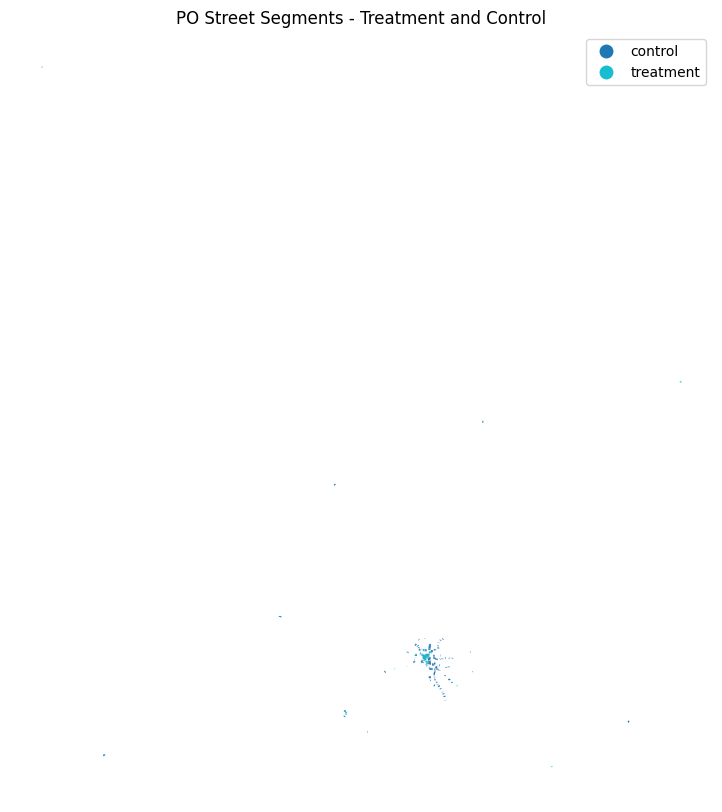

In [30]:
# CELL 12: Analyse treatment/control and intervention coverage spatially

print("=" * 70)
print("SPATIAL TREATMENT, INTERVENTION AND LGA COVERAGE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Treatment vs control distribution
# ------------------------------------------------------------

print("\nTREATMENT / CONTROL DISTRIBUTION")

treatment_summary = (
    streets_gdf[
        "treatment_or_control"
    ]
    .value_counts(dropna=False)
    .rename_axis(
        "Treatment_or_Control"
    )
    .reset_index(
        name="Street_Segments"
    )
)

treatment_summary[
    "Percentage"
] = (
    treatment_summary[
        "Street_Segments"
    ]
    / len(streets_gdf)
    * 100
).round(2)

display(
    treatment_summary
)


# ------------------------------------------------------------
# 2. Intervention types
# ------------------------------------------------------------

print("\nINTERVENTION TYPES")

intervention_spatial_summary = (
    streets_gdf[
        "intervention_type"
    ]
    .value_counts(dropna=False)
    .rename_axis(
        "Intervention_Type"
    )
    .reset_index(
        name="Street_Segments"
    )
)

display(
    intervention_spatial_summary
)


# ------------------------------------------------------------
# 3. CBD / Metro / Regional coverage
# ------------------------------------------------------------

print("\nGEOGRAPHIC AREA FLAGS")

area_summary = pd.DataFrame({
    "Area": [
        "CBD",
        "Metro",
        "Regional"
    ],
    "Street_Segments": [
        int(streets_gdf["cbd"].sum()),
        int(streets_gdf["metro"].sum()),
        int(streets_gdf["regional"].sum())
    ]
})

area_summary[
    "Percentage"
] = (
    area_summary[
        "Street_Segments"
    ]
    / len(streets_gdf)
    * 100
).round(2)

display(
    area_summary
)


# ------------------------------------------------------------
# 4. LGA coverage
# ------------------------------------------------------------

print("\nLGA COVERAGE")

lga_summary = (
    streets_gdf
    .groupby("lga")
    .agg(
        Street_Segments=(
            "street_segment_id",
            "nunique"
        )
    )
    .sort_values(
        "Street_Segments",
        ascending=False
    )
    .reset_index()
)

print(
    "Number of LGAs:",
    len(lga_summary)
)

display(
    lga_summary
)


# ------------------------------------------------------------
# 5. Treatment/control distribution by LGA
# ------------------------------------------------------------

print("\nTREATMENT / CONTROL BY LGA")

lga_treatment = (
    streets_gdf
    .groupby(
        [
            "lga",
            "treatment_or_control"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

display(
    lga_treatment
)


# ------------------------------------------------------------
# 6. Intervention type by LGA
# ------------------------------------------------------------

print("\nINTERVENTION TYPE BY LGA")

lga_intervention = (
    streets_gdf
    .groupby(
        [
            "lga",
            "intervention_type"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

display(
    lga_intervention
)


# ------------------------------------------------------------
# 7. Suburb coverage
# ------------------------------------------------------------

print("\nSUBURB COVERAGE")

suburb_summary = (
    streets_gdf
    .groupby(
        [
            "suburb",
            "lga"
        ]
    )
    .agg(
        Street_Segments=(
            "street_segment_id",
            "nunique"
        )
    )
    .sort_values(
        "Street_Segments",
        ascending=False
    )
    .reset_index()
)

print(
    "Number of suburbs:",
    suburb_summary[
        "suburb"
    ].nunique()
)

display(
    suburb_summary.head(20)
)


# ------------------------------------------------------------
# 8. Join construction-affected segments to spatial attributes
# ------------------------------------------------------------

construction_spatial = (
    streets_gdf[
        [
            "street_segment_id",
            "street_name",
            "suburb",
            "postcode",
            "lga",
            "treatment_or_control",
            "intervention_type",
            "cbd",
            "metro",
            "regional",
            "geometry"
        ]
    ]
    .merge(
        refined_comparison,
        left_on="street_segment_id",
        right_on="STREET_SEGMENT_ID",
        how="inner"
    )
)


print("\nCONSTRUCTION-AFFECTED SPATIAL DATA")

print(
    "Construction segments mapped:",
    len(construction_spatial)
)

print(
    "LGAs represented:",
    construction_spatial[
        "lga"
    ].nunique()
)

print(
    "Suburbs represented:",
    construction_spatial[
        "suburb"
    ].nunique()
)


print("\nCONSTRUCTION SEGMENTS BY INTERVENTION TYPE")

display(
    construction_spatial[
        "intervention_type"
    ]
    .value_counts(dropna=False)
    .rename_axis(
        "Intervention_Type"
    )
    .reset_index(
        name="Street_Segments"
    )
)


print("\nCONSTRUCTION SEGMENTS BY LGA")

display(
    construction_spatial[
        "lga"
    ]
    .value_counts()
    .rename_axis("LGA")
    .reset_index(
        name="Street_Segments"
    )
)


# ------------------------------------------------------------
# 9. Simple spatial plot
# ------------------------------------------------------------

print("\nSPATIAL VIEW")

ax = streets_gdf.plot(
    column="treatment_or_control",
    legend=True,
    figsize=(10, 10)
)

ax.set_title(
    "PO Street Segments - Treatment and Control"
)

ax.set_axis_off()

plt.show()

In [32]:
# CELL 13: Create cleaned working copies of the PO datasets

print("=" * 70)
print("CONTROLLED PO DATA PREPROCESSING")
print("=" * 70)


# ============================================================
# 1. Create copies so the original datasets remain unchanged
# ============================================================

sites_clean = sites_df.copy()
quarterly_clean = quarterly_df.copy()
streets_clean = streets_gdf.copy()
study_area_clean = study_area_gdf.copy()


# ============================================================
# 2. Remove exported index column from quarterly dataset
# ============================================================

if "Unnamed: 0" in quarterly_clean.columns:

    quarterly_clean = quarterly_clean.drop(
        columns=["Unnamed: 0"]
    )

    print("\nRemoved exported index column: Unnamed: 0")


# ============================================================
# 3. Standardise obvious Yes/No text inconsistencies
# ============================================================

yes_no_columns_sites = [
    "StreetTrees",
    "StreetLighting",
    "StreetFurniture",
    "Placemaking",
    "Wayfinding",
    "StreetInScopeOnStreetParking",
    "BufferOnStreetParking",
    "OffStreetParking"
]

for column in yes_no_columns_sites:

    if column in sites_clean.columns:

        sites_clean[column] = (
            sites_clean[column]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({
                "yes": "Yes",
                "no": "No"
            })
        )


print(
    "\nStandardised obvious Yes/No text values "
    "in sites_db."
)


# ============================================================
# 4. Convert PO date fields safely
# ============================================================

date_columns = [
    "DateOfIntervention/InitialCapture",
    "DisruptionStartDate",
    "DisruptionEndDate",
    "NoChangeSince"
]

for column in date_columns:

    if column in sites_clean.columns:

        sites_clean[column + "_parsed"] = pd.to_datetime(
            sites_clean[column]
            .astype("Int64")
            .astype("string"),
            format="%Y%m%d",
            errors="coerce"
        )


print("\nParsed date columns created.")

for column in date_columns:

    parsed_column = column + "_parsed"

    if parsed_column in sites_clean.columns:

        print(
            parsed_column,
            "- valid dates:",
            sites_clean[parsed_column].notna().sum()
        )


# ============================================================
# 5. Standardise key ID types
# ============================================================

sites_clean["StreetSegmentID"] = (
    sites_clean["StreetSegmentID"]
    .astype("Int64")
)

quarterly_clean["STREET_SEGMENT_ID"] = (
    quarterly_clean["STREET_SEGMENT_ID"]
    .astype("Int64")
)

streets_clean["street_segment_id"] = (
    streets_clean["street_segment_id"]
    .astype("Int64")
)

study_area_clean["street_segment_id"] = (
    study_area_clean["street_segment_id"]
    .astype("Int64")
)


print("\nStreet segment ID types standardised.")


# ============================================================
# 6. Create easier-to-read treatment labels
# ============================================================

streets_clean["treatment_or_control_clean"] = (
    streets_clean[
        "treatment_or_control"
    ]
    .astype("string")
    .str.strip()
    .str.lower()
)


streets_clean["intervention_type_clean"] = (
    streets_clean[
        "intervention_type"
    ]
    .astype("string")
    .str.strip()
    .str.lower()
)


print(
    "\nTreatment/control and intervention labels standardised."
)


# ============================================================
# 7. Keep unusual parking format value for review
#    rather than silently correcting it
# ============================================================

unusual_buffer_formats = (
    sites_clean[
        "BufferOnStreetParkingFormat"
    ]
    .value_counts(dropna=False)
)

print("\nBUFFER PARKING FORMAT VALUES")

display(
    unusual_buffer_formats
    .rename_axis("Format")
    .reset_index(name="Records")
)


# ============================================================
# 8. Check parsed date ranges
# ============================================================

print("\nDATE COVERAGE")

for column in date_columns:

    parsed_column = column + "_parsed"

    if parsed_column in sites_clean.columns:

        valid_dates = (
            sites_clean[parsed_column]
            .dropna()
        )

        if len(valid_dates) > 0:

            print(
                f"\n{parsed_column}"
            )

            print(
                "Earliest:",
                valid_dates.min()
            )

            print(
                "Latest:",
                valid_dates.max()
            )


# ============================================================
# 9. Confirm that preprocessing did not remove records
# ============================================================

print("\nRECORD COUNT CHECK")

print(
    "Original sites_db rows:",
    len(sites_df)
)

print(
    "Clean working sites rows:",
    len(sites_clean)
)

print(
    "Original quarterly rows:",
    len(quarterly_df)
)

print(
    "Clean working quarterly rows:",
    len(quarterly_clean)
)

print(
    "Original streets spatial rows:",
    len(streets_gdf)
)

print(
    "Clean working streets rows:",
    len(streets_clean)
)


# ============================================================
# 10. Final column counts after preprocessing
# ============================================================

print("\nCLEAN WORKING DATASET STRUCTURE")

print(
    "sites_clean columns:",
    len(sites_clean.columns)
)

print(
    "quarterly_clean columns:",
    len(quarterly_clean.columns)
)

print(
    "streets_clean columns:",
    len(streets_clean.columns)
)

print(
    "study_area_clean columns:",
    len(study_area_clean.columns)
)


print(
    "\nControlled preprocessing completed."
)

CONTROLLED PO DATA PREPROCESSING

Removed exported index column: Unnamed: 0

Standardised obvious Yes/No text values in sites_db.

Parsed date columns created.
DateOfIntervention/InitialCapture_parsed - valid dates: 637
DisruptionStartDate_parsed - valid dates: 235
DisruptionEndDate_parsed - valid dates: 289
NoChangeSince_parsed - valid dates: 195

Street segment ID types standardised.

Treatment/control and intervention labels standardised.

BUFFER PARKING FORMAT VALUES


,Format,Records
0,Mixed,322
1,Parallel,288
2,NaN,15
3,Angled,7
4,90 Degree,4
5,High,1



DATE COVERAGE

DateOfIntervention/InitialCapture_parsed
Earliest: 2007-11-30 00:00:00
Latest: 2025-12-12 00:00:00

DisruptionStartDate_parsed
Earliest: 2007-11-30 00:00:00
Latest: 2025-04-16 00:00:00

DisruptionEndDate_parsed
Earliest: 2009-10-12 00:00:00
Latest: 2025-12-12 00:00:00

NoChangeSince_parsed
Earliest: 2007-11-01 00:00:00
Latest: 2025-10-15 00:00:00

RECORD COUNT CHECK
Original sites_db rows: 637
Clean working sites rows: 637
Original quarterly rows: 30783
Clean working quarterly rows: 30783
Original streets spatial rows: 315
Clean working streets rows: 315

CLEAN WORKING DATASET STRUCTURE
sites_clean columns: 39
quarterly_clean columns: 14
streets_clean columns: 13
study_area_clean columns: 2

Controlled preprocessing completed.


In [34]:
# CELL 14: Save PO EDA outputs and create current dataset assessment

print("=" * 70)
print("PO DATASET CURRENT ASSESSMENT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

analysis_output.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Save cleaned tabular datasets
# ------------------------------------------------------------

sites_clean.to_csv(
    analysis_output / "sites_db_clean.csv",
    index=False
)

quarterly_clean.to_csv(
    analysis_output / "street_segment_qtr_attributes_clean.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Save useful summary tables
# ------------------------------------------------------------

sites_missing.to_csv(
    analysis_output / "sites_missing_values_summary.csv",
    index=False
)

quarterly_missing.to_csv(
    analysis_output / "quarterly_missing_values_summary.csv",
    index=False
)

quarter_coverage.to_csv(
    analysis_output / "quarterly_coverage_summary.csv",
    index=False
)

construction_by_quarter.to_csv(
    analysis_output / "construction_by_quarter.csv",
    index=False
)

baseline_parking_summary.to_csv(
    analysis_output / "baseline_parking_summary.csv",
    index=False
)

intervention_parking_summary.to_csv(
    analysis_output / "intervention_parking_summary.csv",
    index=False
)

refined_comparison.to_csv(
    analysis_output / "construction_parking_comparison.csv",
    index=False
)

treatment_summary.to_csv(
    analysis_output / "treatment_control_summary.csv",
    index=False
)

intervention_spatial_summary.to_csv(
    analysis_output / "spatial_intervention_summary.csv",
    index=False
)

lga_summary.to_csv(
    analysis_output / "lga_coverage_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save processed spatial datasets
# ------------------------------------------------------------

streets_clean.to_file(
    analysis_output / "streets_spatial_clean.gpkg",
    driver="GPKG"
)

study_area_clean.to_file(
    analysis_output / "street_spatial_study_area_clean.gpkg",
    driver="GPKG"
)


# ------------------------------------------------------------
# 5. Calculate key values for the current assessment
# ------------------------------------------------------------

construction_segments = (
    refined_comparison[
        "STREET_SEGMENT_ID"
    ].nunique()
)

capacity_decrease = (
    refined_comparison[
        "Capacity_Change"
    ] < 0
).sum()

capacity_same = (
    refined_comparison[
        "Capacity_Change"
    ] == 0
).sum()

capacity_increase = (
    refined_comparison[
        "Capacity_Change"
    ] > 0
).sum()

median_capacity_change = (
    refined_comparison[
        "Capacity_Change"
    ].median()
)


# ------------------------------------------------------------
# 6. Print current assessment
# ------------------------------------------------------------

print("\nDATASET STRUCTURE")

print(
    "sites_db records:",
    f"{len(sites_clean):,}"
)

print(
    "quarterly attribute records:",
    f"{len(quarterly_clean):,}"
)

print(
    "quarterly street segments:",
    quarterly_clean[
        "STREET_SEGMENT_ID"
    ].nunique()
)

print(
    "street geometries:",
    len(streets_clean)
)

print(
    "study-area geometries:",
    len(study_area_clean)
)


print("\nTEMPORAL COVERAGE")

print(
    "Quarterly periods:",
    quarterly_df["QUARTER"].nunique()
)

print(
    "First quarter:",
    quarterly_df["QUARTER"].drop_duplicates().iloc[0]
)

print(
    "Latest quarter:",
    quarterly_df["QUARTER"].drop_duplicates().iloc[-1]
)

print(
    "Earliest parsed intervention/initial-capture date:",
    sites_clean[
        "DateOfIntervention/InitialCapture_parsed"
    ].min()
)

print(
    "Latest parsed intervention/initial-capture date:",
    sites_clean[
        "DateOfIntervention/InitialCapture_parsed"
    ].max()
)


print("\nINTERVENTION AND SPATIAL COVERAGE")

print(
    "Treatment street segments:",
    (
        streets_clean[
            "treatment_or_control_clean"
        ] == "treatment"
    ).sum()
)

print(
    "Control street segments:",
    (
        streets_clean[
            "treatment_or_control_clean"
        ] == "control"
    ).sum()
)

print(
    "LGAs represented:",
    streets_clean["lga"].nunique()
)

print(
    "Suburbs represented:",
    streets_clean["suburb"].nunique()
)

print(
    "Construction-affected segments:",
    construction_segments
)

print(
    "Construction segments with spatial geometry:",
    len(
        set(
            refined_comparison[
                "STREET_SEGMENT_ID"
            ].astype(int)
        )
        &
        set(
            streets_clean[
                "street_segment_id"
            ].astype(int)
        )
    )
)


print("\nPARKING CAPACITY AROUND CONSTRUCTION")

print(
    "Segments with decreased capacity:",
    capacity_decrease
)

print(
    "Segments with no capacity change:",
    capacity_same
)

print(
    "Segments with increased capacity:",
    capacity_increase
)

print(
    "Median observed capacity change:",
    median_capacity_change
)


print("\nCURRENT DATA QUALITY / LIMITATIONS")

print(
    "- sites_db required cp1252 encoding rather than UTF-8."
)

print(
    "- Some intervention-related missing values are structural "
    "and should not automatically be treated as errors."
)

print(
    "- The quarterly dataset contains repeated "
    "street-segment/quarter combinations that can represent "
    "different site or baseline states."
)

print(
    "- Three quarterly street-segment IDs are not present "
    "in the streets spatial dataset."
)

print(
    "- The study-area file contains one extra segment "
    "(3500) that is not present in streets_spatial."
)

print(
    "- Spatial datasets use different CRS values, so "
    "reprojection is required before spatial comparison "
    "with the wider road network."
)

print(
    "- BufferOnStreetParkingFormat contains one unusual "
    "'High' value that requires manual review."
)

print(
    "- Parking capacity changes are observations around "
    "construction periods and should not yet be interpreted "
    "as causal effects."
)


print("\nCURRENT PROJECT USE")

print(
    "- The quarterly PO dataset provides a long historical "
    "framework for intervention and construction analysis."
)

print(
    "- Construction periods can be identified using "
    "is_under_construction."
)

print(
    "- Parking capacity can be compared before and after "
    "construction for the affected street segments."
)

print(
    "- All construction-affected segments used in the current "
    "comparison have spatial geometry available."
)

print(
    "- PO street-segment IDs provide a basis for later matching "
    "with suitable external traffic and climate datasets."
)


# ------------------------------------------------------------
# 7. List saved files
# ------------------------------------------------------------

print("\nOUTPUT FILES CREATED")

for file in sorted(
    analysis_output.iterdir()
):
    print("-", file.name)


print(
    "\nPO EDA and preprocessing outputs saved successfully."
)

PO DATASET CURRENT ASSESSMENT

DATASET STRUCTURE
sites_db records: 637
quarterly attribute records: 30,783
quarterly street segments: 292
street geometries: 315
study-area geometries: 316

TEMPORAL COVERAGE
Quarterly periods: 105
First quarter: 9900Q2
Latest quarter: 2526Q2
Earliest parsed intervention/initial-capture date: 2007-11-30 00:00:00
Latest parsed intervention/initial-capture date: 2025-12-12 00:00:00

INTERVENTION AND SPATIAL COVERAGE
Treatment street segments: 96
Control street segments: 219
LGAs represented: 29
Suburbs represented: 111
Construction-affected segments: 69
Construction segments with spatial geometry: 69

PARKING CAPACITY AROUND CONSTRUCTION
Segments with decreased capacity: 52
Segments with no capacity change: 10
Segments with increased capacity: 7
Median observed capacity change: -8.0

CURRENT DATA QUALITY / LIMITATIONS
- sites_db required cp1252 encoding rather than UTF-8.
- Some intervention-related missing values are structural and should not automaticall